# Lifecycle retirement: when to stop working

A lifecycle consumption-savings problem where the agent chooses **when
to retire** as well as how much to consume each period. Retirement is
a one-way switch (no un-retiring) — the natural use case for
`DiscreteState`: the agent supplies the dynamics (an absorbing
transition once they retire), the solver doesn't need a transition
matrix.

## Problem

State $(w_t, \tau_t)$ where $w_t$ is wealth and $\tau_t \in
\{\mathrm{working}, \mathrm{retired}\}$ is the irreversible
retirement phase. Two actions each period:

- **consume** $c_t \in [0, w_t]$ (continuous, with the no-borrowing
  constraint),
- **retire** $\in \{0, 1\}$ (only effective from the working phase;
  once retired, the agent stays retired).

Income $y_t$ is realized only while working:

$$ y_t = \begin{cases} \mu_y + \sigma_y\,Z_t, \;\; Z_t \sim \mathcal{N}(0,1) & \text{if } \tau_t = \text{working} \\ 0 & \text{if } \tau_t = \text{retired} \end{cases} $$

Wealth evolves as

$$ w_{t+1} = R\,(w_t - c_t) + y_t. $$

Per-period reward includes a **leisure bonus** $L$ enjoyed only in
retirement:

$$ r_t = \log c_t + L \cdot \mathbf{1}\{\tau_t = \text{retired}\}. $$

Phase transitions deterministically: once the agent picks
$\text{retire}_t = 1$ from the working phase, they're retired from
the next period onward.

**Tradeoff**: working keeps income flowing but costs the leisure
bonus; retiring captures $L$ each period but cuts off income. The
optimal retirement time depends on (i) accumulated wealth and (ii)
the remaining horizon — both make the income stream less valuable
relative to leisure.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from bellgrid import (
    ContinuousAction,
    ContinuousState,
    DiscreteAction,
    DiscreteState,
    Problem,
    simulate,
    solve,
)
from bellgrid.grids import RegularGrid, WarpedGrid
from bellgrid.shocks import Normal
from bellgrid.solvers import BackwardInduction

## Parameters

In [2]:
beta = 0.96       # annual discount
R = 1.04          # gross return on savings
mu_y = 1.0        # mean labor income (one unit per period)
sigma_y = 0.1     # income shock std
L = 0.6           # per-period leisure bonus (utility units)
T = 40            # life-cycle horizon (periods)

## Bellgrid problem

Note the `DiscreteState` semantics: the user-supplied `transition`
callable explicitly returns the next phase, encoding the absorbing
"once retired, stay retired" rule. (Contrast with `MarkovChain`,
where the solver advances the state via a built-in matrix.)

In [3]:
mu_y_t = torch.tensor(mu_y, dtype=torch.float64)
sigma_y_t = torch.tensor(sigma_y, dtype=torch.float64)


def transition(state, action, shock, _t):
    w = state["wealth"]
    phase = state["phase"]  # 0 = working, 1 = retired
    c = action["consume"]
    retire = action["retire"]
    # Income only flows while currently working
    income = torch.where(
        phase == 0,
        mu_y_t + sigma_y_t * shock["z"],
        torch.zeros_like(w),
    )
    next_w = R * (w - c) + income
    # Absorbing: phase=1 stays 1; phase=0 stays 0 unless retire is chosen
    next_phase = torch.where(
        (phase == 0) & (retire == 0),
        torch.zeros_like(phase),
        torch.ones_like(phase),
    )
    return {"wealth": next_w, "phase": next_phase}


def reward(state, action, _shock, _t):
    leisure = L * (state["phase"] == 1).to(action["consume"].dtype)
    return torch.log(action["consume"]) + leisure


problem = Problem(
    states=[
        ContinuousState("wealth", warp="asinh", range=(0.1, 100.0)),
        DiscreteState("phase", n=2, labels=("working", "retired")),
    ],
    actions=[
        ContinuousAction("consume", bounds=(1e-4, "wealth")),
        DiscreteAction("retire", n=2, labels=("continue", "retire")),
    ],
    transition=transition,
    reward=reward,
    shocks=[Normal("z", sigma=1.0)],
    horizon=range(0, T),
    discount=beta,
)

policy, value = solve(
    problem,
    state_grid={"wealth": WarpedGrid(n=128)},
    action_grid={"consume": RegularGrid(n=200)},
    solver=BackwardInduction(n_quad=7),
)

## Retirement boundary across age

For each period $t$ and each wealth level $w$, the optimal policy
tells us whether a still-working agent would retire. The lowest
wealth at which a working agent retires gives the **retirement
boundary** $w^*(t)$.

It's downward-sloping in $t$: when there's lots of remaining horizon,
you'd only retire if very rich (the future income stream is too
valuable to give up); near the end of the horizon, the income stream
is worth little and you retire at much lower wealth.

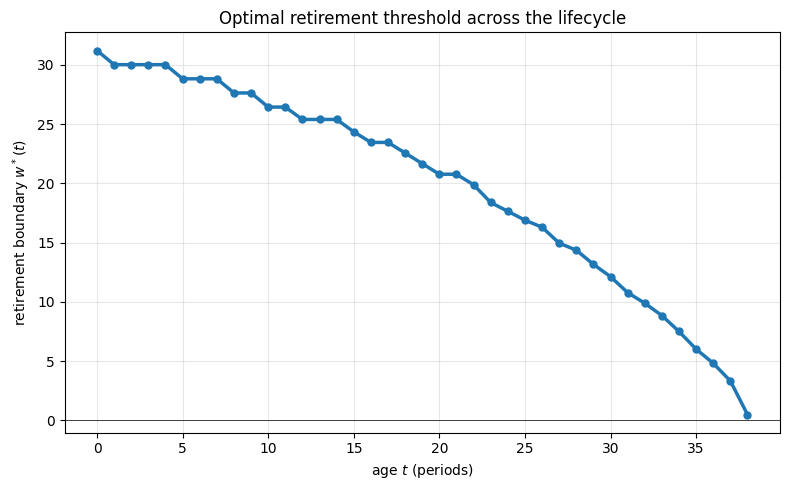

In [4]:
w_search = np.linspace(0.5, 60.0, 400)
boundary = []
for t in range(T):
    w_t = torch.tensor(w_search, dtype=torch.float64)
    p_t = torch.zeros(400, dtype=torch.long)
    a = policy({"wealth": w_t, "phase": p_t}, t=t)
    retire_dec = a["retire"].numpy()
    idx = np.where(retire_dec == 1)[0]
    boundary.append(w_search[idx[0]] if len(idx) > 0 else np.nan)
boundary = np.array(boundary)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(T), boundary, "o-", lw=2.5, markersize=5, color="C0")
ax.set_xlabel("age $t$ (periods)")
ax.set_ylabel("retirement boundary $w^*(t)$")
ax.set_title("Optimal retirement threshold across the lifecycle")
ax.grid(alpha=0.3)
ax.axhline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()

## Consumption rate by phase

At the same wealth, **retired** agents consume more (no future
income to draw against, so the marginal value of saving is lower).
**Working** agents save more out of any given dollar because future
income gives them a safety net.

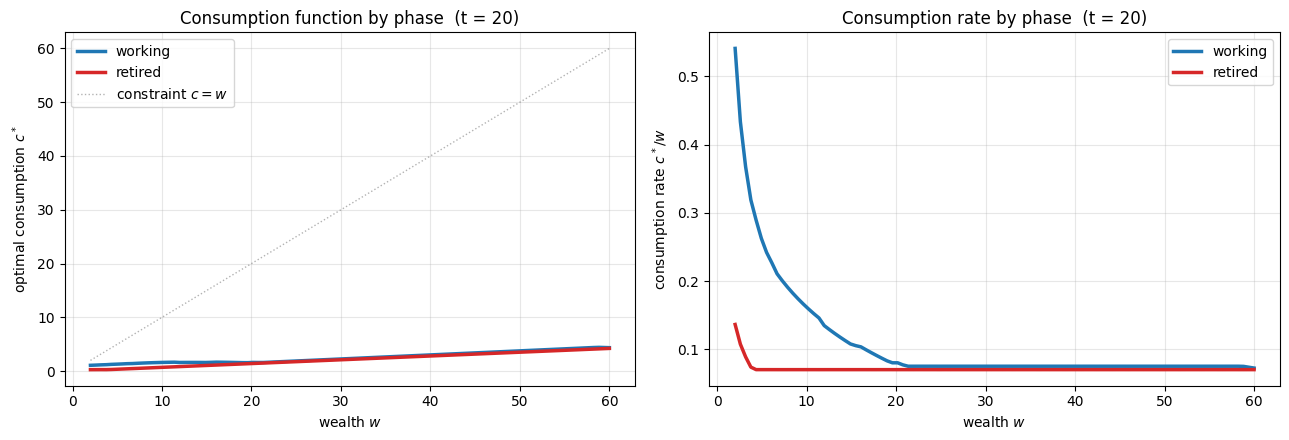

In [5]:
w_query = torch.linspace(2.0, 60.0, 100, dtype=torch.float64)
w_np = w_query.numpy()

c_working = policy(
    {"wealth": w_query, "phase": torch.zeros(100, dtype=torch.long)},
    t=T // 2,
)["consume"].numpy()
c_retired = policy(
    {"wealth": w_query, "phase": torch.ones(100, dtype=torch.long)},
    t=T // 2,
)["consume"].numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(w_np, c_working, lw=2.5, color="C0", label="working")
ax1.plot(w_np, c_retired, lw=2.5, color="C3", label="retired")
ax1.plot(w_np, w_np, ls=":", lw=1.0, color="gray", alpha=0.6, label="constraint $c = w$")
ax1.set_xlabel("wealth $w$")
ax1.set_ylabel("optimal consumption $c^*$")
ax1.set_title(f"Consumption function by phase  (t = {T // 2})")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(w_np, c_working / w_np, lw=2.5, color="C0", label="working")
ax2.plot(w_np, c_retired / w_np, lw=2.5, color="C3", label="retired")
ax2.set_xlabel("wealth $w$")
ax2.set_ylabel("consumption rate $c^* / w$")
ax2.set_title(f"Consumption rate by phase  (t = {T // 2})")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Retirement decision heatmap

Full retirement decision over (wealth, age). Yellow region: agent
retires. Blue region: keeps working. The boundary curve from the
first plot is the contour between the two.

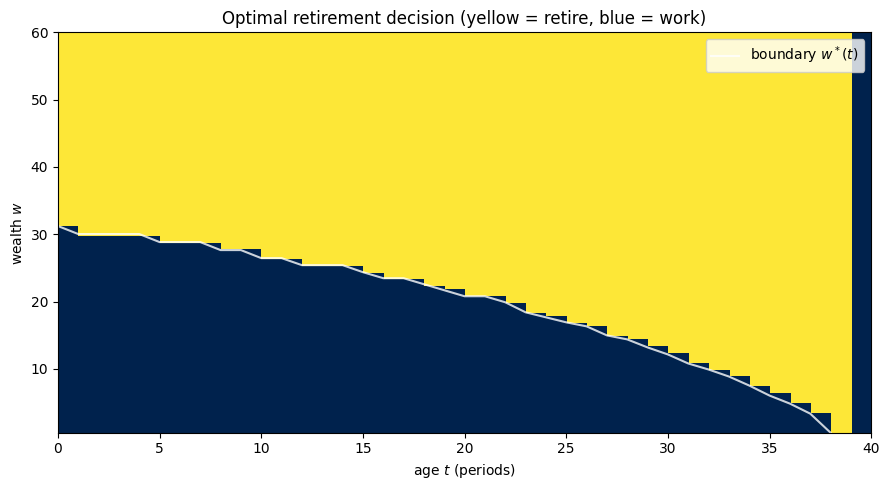

In [6]:
w_grid_h = np.linspace(0.5, 60.0, 120)
retire_grid = np.zeros((T, len(w_grid_h)))
for t in range(T):
    w_t = torch.tensor(w_grid_h, dtype=torch.float64)
    p_t = torch.zeros(len(w_grid_h), dtype=torch.long)
    retire_grid[t] = policy({"wealth": w_t, "phase": p_t}, t=t)["retire"].numpy()

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(
    retire_grid.T, origin="lower", aspect="auto",
    extent=[0, T, w_grid_h[0], w_grid_h[-1]],
    cmap="cividis",
)
ax.plot(np.arange(T), boundary, color="white", lw=1.5, alpha=0.8,
        label="boundary $w^*(t)$")
ax.set_xlabel("age $t$ (periods)")
ax.set_ylabel("wealth $w$")
ax.set_title("Optimal retirement decision (yellow = retire, blue = work)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Forward simulation: accumulation → retirement → decumulation

500 paths starting from wealth $w_0 = 5$ in the working phase.
Trajectories follow the canonical lifecycle pattern: working agents
accumulate wealth, eventually cross the retirement boundary and
retire, then decumulate. Income shocks make the retirement age
slightly random across paths.

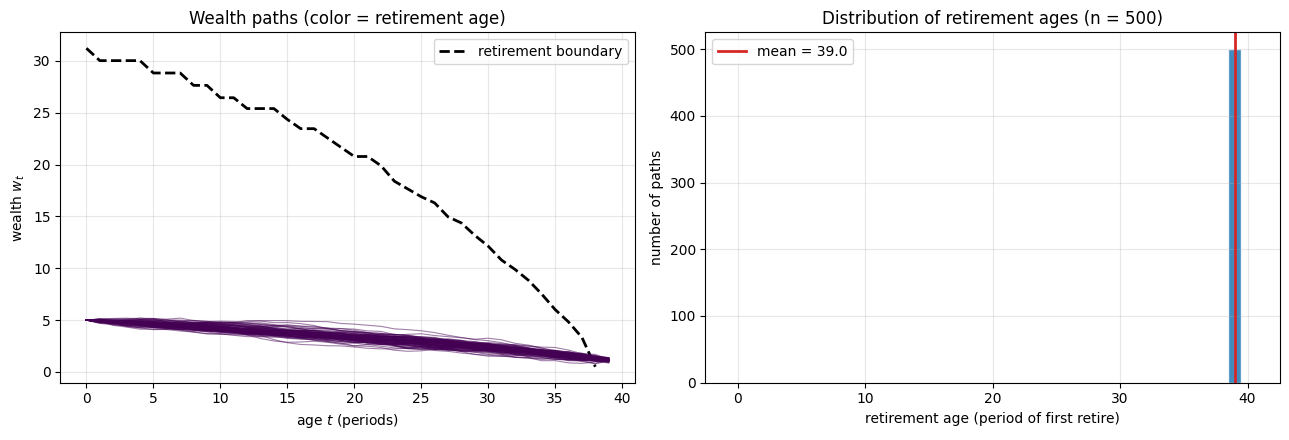

Median retirement age: 39.0 of 40 periods
Mean retirement age:   39.0
Fraction never retiring (capped at T): 0.0%


In [7]:
n_paths = 500
paths = simulate(
    policy=policy,
    problem=problem,
    n=n_paths,
    initial_state={"wealth": 5.0, "phase": 0},
    seed=42,
)
paths_cpu = {k: v.cpu() for k, v in paths.items()}
wealth_paths = paths_cpu["wealth"].numpy()
phase_paths = paths_cpu["phase"].numpy()

# Find retirement period for each path (first t at which phase = 1)
retirement_age = np.full(n_paths, T)  # never-retired sentinel
for i in range(n_paths):
    retired_idx = np.where(phase_paths[i] == 1)[0]
    if len(retired_idx) > 0:
        retirement_age[i] = retired_idx[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
# Color a sample of paths by retirement age
sample_idx = np.random.RandomState(0).choice(n_paths, size=80, replace=False)
ax1.plot(np.arange(T), boundary, color="black", lw=2, ls="--",
         label="retirement boundary")
for i in sample_idx:
    ret_age = retirement_age[i]
    color = plt.cm.viridis((ret_age - retirement_age.min()) /
                            max(1, retirement_age.max() - retirement_age.min()))
    ax1.plot(np.arange(T), wealth_paths[i], color=color, alpha=0.5, lw=0.8)
ax1.set_xlabel("age $t$ (periods)")
ax1.set_ylabel("wealth $w_t$")
ax1.set_title("Wealth paths (color = retirement age)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.hist(retirement_age, bins=np.arange(T + 2) - 0.5, color="C0",
         edgecolor="white", alpha=0.85)
ax2.axvline(retirement_age.mean(), color="C3", lw=2,
            label=f"mean = {retirement_age.mean():.1f}")
ax2.set_xlabel("retirement age (period of first retire)")
ax2.set_ylabel("number of paths")
ax2.set_title(f"Distribution of retirement ages (n = {n_paths})")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Median retirement age: {np.median(retirement_age):.1f} of {T} periods")
print(f"Mean retirement age:   {retirement_age.mean():.1f}")
print(f"Fraction never retiring (capped at T): "
      f"{(retirement_age == T).mean():.1%}")